# 15 Minutes to CQEDToolbox
## Single Qubit Measurements

 This is a short guide on how to perform a qubit measurement. It consists of setting up the protocols, performing the measurements, and analyzing the results. 


## Setting Up

The following repositories must be cloned before we start:

``` git clone https://github.com/toolsforexperiments/labcore.git ../labcore```

``` git clone https://github.com/toolsforexperiments/instrumentserver.git ../instrumentserver```



Then, install the following:

```pip install -e ../labcore```

```pip install -e ../instrumentserver```

```pip install -e ".[dev]" ```

The final installation will automatically install Qick through PyPI, which is also required. For dummy mode, the PyPI version installed automatically is sufficient. However, the hardware modes require a local editable install.

## Importing the Basics

In [33]:
import labcore.protocols.base as _base
from labcore.protocols.base import PlatformTypes
from instrumentserver.params import ParameterManager

import json
from pathlib import Path

For this walkthrough, we will be running the protocols in dummy mode. This mode does not require any hardware to be used alongside the protocols. Instead, it uses the `DataGen` class in `labcore` to simulate realistic measurements, allowing the full protocol pipeline — fitting, corrections, and reporting — to be tested without any hardware connected. More information on `DataGen` can be found [here](https://github.com/toolsforexperiments/labcore/blob/main/src/labcore/data/datagen.py). More information on the non-dummy modes (OPX and Qick) can be found [here](https://github.com/toolsforexperiments/CQEDToolbox/tree/main/src/cqedtoolbox/instruments).



We must set the protocols to dummy mode before we import them:

In [3]:
_base.PLATFORMTYPE = PlatformTypes.DUMMY

from cqedtoolbox.protocols.operations.single_qubit.res_spec import ResonatorSpectroscopy
from cqedtoolbox.protocols.operations.single_qubit.res_spec_after_pi import ResonatorSpectroscopyAfterPi
from cqedtoolbox.protocols.operations.single_qubit.res_spec_vs_gain import ResonatorSpectroscopyVsGain
from cqedtoolbox.protocols.operations.single_qubit.sat_spec import SaturationSpectroscopy
from cqedtoolbox.protocols.operations.single_qubit.pi_spec import PiSpectroscopy
from cqedtoolbox.protocols.operations.single_qubit.power_rabi import PowerRabi
from cqedtoolbox.protocols.operations.single_qubit.t1 import T1Operation
from cqedtoolbox.protocols.operations.single_qubit.t2r import T2ROperation
from cqedtoolbox.protocols.operations.single_qubit.t2e import T2EOperation

All ```ProtocolOperation``` classes require a `params` object to be passed. For this walkthrough, we will use [this parameter_manager file](https://github.com/toolsforexperiments/CQEDToolbox/blob/main/src/cqedtoolbox/protocols/configs/parameter_manager-dummy_config.json) in the CQEDToolbox repository.

The parameter-manager file should be in the working directory. Otherwise, we would have to specify the working directory.

In [42]:
params = ParameterManager('parameter_manager')
params.fromFile('parameter_manager-dummy_config.json')

for name in params.list()[:10]:
    print(f"{name}: {params.get(name)}")

parameter file not found, cannot load.
parameter file not found, cannot load.
parameter file not found, cannot load.
parameter file not found, cannot load.
parameter file not found, cannot load.
parameter file not found, cannot load.
parameter file not found, cannot load.
parameter file not found, cannot load.
parameter file not found, cannot load.


active.qubit: q01
msmt_params.delay: 1.0
q01.pulses.pi.amp: 0.4991246743723084
q01.readout.IF: 7000004054.426136
q01.readout.LO: 0.0
q01.IF: 5000009106.68956
q01.LO: 0.0
q01.T1: 19.05847321877821
q01.T2E: 24.920766961424665
q01.T2R: 9.847294302273214


## Measurements

Now that everything is set up, we can run our first dummy measurement using the ResonatorSpectroscopy protocol. All of the single-qubit protocols can be found [here](https://github.com/toolsforexperiments/CQEDToolbox/tree/main/src/cqedtoolbox/protocols/operations/single_qubit).

In [34]:
protocol = ResonatorSpectroscopy(params)

protocol.measure()
protocol.load_data()
protocol.analyze()

data 'fit_curve', type <class 'numpy.ndarray'>could not be saved regularly, try pickle instead...
Could not pickle fit_curve.
data 'fit_curve', type <class 'numpy.ndarray'>could not be saved regularly, try pickle instead...
Could not pickle fit_curve.


The cell above completes the protocol in three steps. First, it runs the protocol's dummy sweep and returns the path to the data. Then, that data is used to populate the protocol's independent and dependent variable arrays. Finally, the arrays are used to create an analysis of the protocol.

We can now see that two folders were created in the working directory: `data` and `analysis`. The `data` folder is organized by date and timestamp. One subfolder is generated for each protocol that is run and contains three items: an analysis folder of the protocol, an HDF5 file with the measurement data, and a tag that signifies the protocol completed successfully. The `analysis` folder mirrors the analysis subfolders from data in one place, making it easy to browse results from many runs without navigating into each timestamped folder.

The contents of `data` are printed below.

In [40]:
print("Data contents:")
for f in Path('./data/2026-04-27/2026-04-27T233258_55523911-ResonatorSpectroscopy').iterdir():
    print(f)


print("\nProtocol analysis contents:")
for f in Path('./data/2026-04-27/2026-04-27T233258_55523911-ResonatorSpectroscopy/ResonatorSpectroscopy').iterdir():
    print(f)


Data contents:
data\2026-04-27\2026-04-27T233258_55523911-ResonatorSpectroscopy\data.ddh5
data\2026-04-27\2026-04-27T233258_55523911-ResonatorSpectroscopy\ResonatorSpectroscopy
data\2026-04-27\2026-04-27T233258_55523911-ResonatorSpectroscopy\__complete__.tag

Protocol analysis contents:
data\2026-04-27\2026-04-27T233258_55523911-ResonatorSpectroscopy\ResonatorSpectroscopy\2026-04-27T233302_fit_curve.json
data\2026-04-27\2026-04-27T233258_55523911-ResonatorSpectroscopy\ResonatorSpectroscopy\2026-04-27T233302_fit_result_lmfit_report.txt
data\2026-04-27\2026-04-27T233258_55523911-ResonatorSpectroscopy\ResonatorSpectroscopy\2026-04-27T233302_fit_result_params.json
data\2026-04-27\2026-04-27T233258_55523911-ResonatorSpectroscopy\ResonatorSpectroscopy\2026-04-27T233302_params.json
data\2026-04-27\2026-04-27T233258_55523911-ResonatorSpectroscopy\ResonatorSpectroscopy\2026-04-27T233302_ResonatorSpectroscopy.pdf
data\2026-04-27\2026-04-27T233258_55523911-ResonatorSpectroscopy\ResonatorSpectrosc

The protocol analysis contains a few important files, including the fit report, parameters, SNR used for fitting, and a plot of the data. Let's take a look at what our protocol looks like.

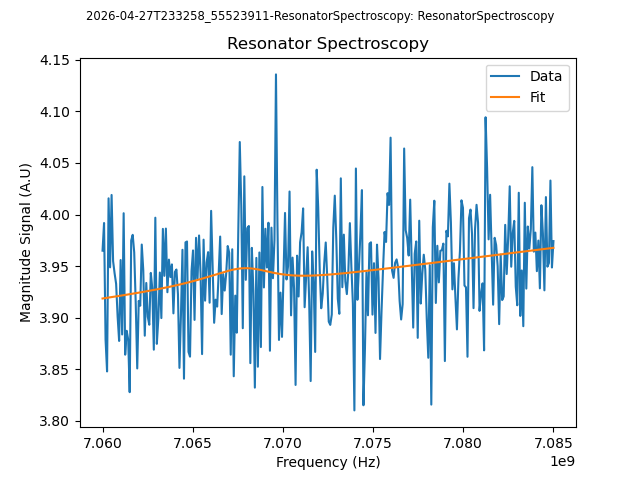

In [36]:
from IPython.display import Image
Image('./data/2026-04-27/2026-04-27T233258_55523911-ResonatorSpectroscopy/ResonatorSpectroscopy/2026-04-27T233302_ResonatorSpectroscopy.png')


Our data looks like just noise because we are sweeping over the wrong frequency range. We missed the expected dip, so let's sweep over another range.

In [ ]:
print("Before:")
print("Start - " + str(params.get('q01.res_spec_start')))
print("End - " + str(params.get('q01.res_spec_end')))


params.q01.res_spec_start(6987500000.0)
params.q01.res_spec_end(7012500000.0)

print("\nAfter:")
print("Start - " + str(params.get('q01.res_spec_start')))
print("End - " + str(params.get('q01.res_spec_end')))


Before:
Start - 7060000000.0
End - 7085000000.0

After:
Start - 6987500000.0
End - 7012500000.0


In [45]:
protocol = ResonatorSpectroscopy(params)

protocol.measure()
protocol.load_data()
protocol.analyze()

data 'fit_curve', type <class 'numpy.ndarray'>could not be saved regularly, try pickle instead...
Could not pickle fit_curve.
data 'fit_curve', type <class 'numpy.ndarray'>could not be saved regularly, try pickle instead...
Could not pickle fit_curve.


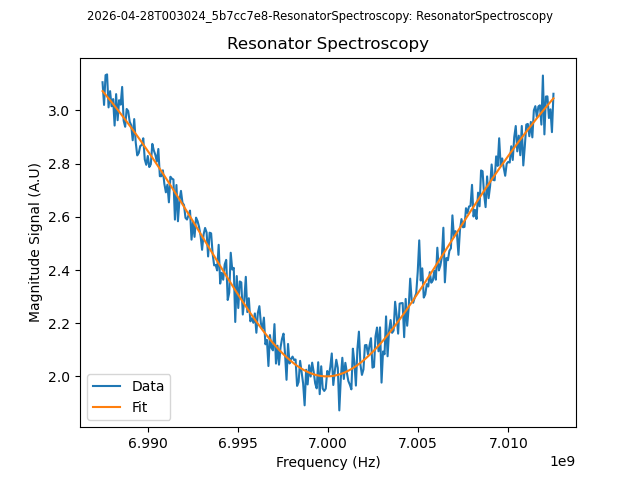

In [46]:
Image('./data/2026-04-28/2026-04-28T003024_5b7cc7e8-ResonatorSpectroscopy/ResonatorSpectroscopy/2026-04-28T003028_ResonatorSpectroscopy.png')

This graph looks much better. However, it can be quite tedious to manually shift the range that we want to sweep over. To address this issue, every protocol uses `Correction` and `CorrectionParameter` classes to automatically adjust the range that we sweep over in the case that our initial range was not sufficient. For example, the `WindowShiftCorrection` for `ResonatorSpectroscopy`, will automatically shift the sweep window by multiples of the original span until the resonance dip is found.